# UML OCR to Mermaid Pipeline
End-to-End Pipeline for processing sketched UMLs into Mermaid.js format.

In [ ]:
# Abhängigkeiten installieren
%pip install transformers torch pillow opencv-python requests

import os
import cv2
import glob
import torch
import base64
import requests
import numpy as np
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from IPython.display import display, Image as IPyImage, Markdown

# Gerätewahl
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Note: you may need to restart the kernel to use updated packages.
Using device: cpu



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
print("Loading TrOCR model...")
model_name = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
print("Model loaded successfully.")


Loading TrOCR model...


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully.


In [ ]:
def preprocess_and_segment(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image: {image_path}")
        return None, []
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Schwellwert
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                   cv2.THRESH_BINARY_INV, 11, 2)

    # Morphologie
    kernel = np.ones((5,5), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    
    # Konturen finden
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    box_images = []
    # Konturen sortieren nach y-Koordinate
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 1000: # Filter für zu kleine Objekte
            x, y, w, h = cv2.boundingRect(cnt)
            # Zuschneiden
            crop = img[y:y+h, x:x+w]
            box_images.append(crop)
            
            # Zeichnen der Konturen
            cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            
    return img, box_images


In [ ]:
def recognize_handwriting(image_crop):
    # OpenCV BGR zu PIL RGB konvertieren
    image = Image.fromarray(cv2.cvtColor(image_crop, cv2.COLOR_BGR2RGB))

    # Pre-process
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    # Inference
    generated_ids = model.generate(pixel_values, max_length=64)
    
    # Decode
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    return generated_text.strip()


In [ ]:
def generate_mermaid_code(diagram_type, texts):
    if diagram_type == "flow-chart":
        mermaid_code = "graph TD;\n"
        for i, text in enumerate(texts):
            clean_text = text.replace('"', '').replace(';', '')
            mermaid_code += f'    Node{i}["{clean_text}"]\n'
            # Sequentiell verbinden
            if i > 0:
                mermaid_code += f'    Node{i-1} --> Node{i}\n'
                
    elif diagram_type == "state-diagram":
        mermaid_code = "stateDiagram-v2\n"
        mermaid_code += "    [*] --> State0\n"
        for i, text in enumerate(texts):
            clean_text = text.replace('"', '').replace(';', '')
            mermaid_code += f'    State{i} : {clean_text}\n'
            if i > 0:
                mermaid_code += f'    State{i-1} --> State{i}\n'
        mermaid_code += f'    State{len(texts)-1} --> [*]\n'
    else:
        mermaid_code = "graph TD;\n    A[Unknown Diagram Type]"
        
    return mermaid_code

def render_mermaid_to_image(mermaid_code, output_path):
    # Base64 encode mermaid code
    b64 = base64.b64encode(mermaid_code.encode('utf-8')).decode('utf-8')
    # mermaid.ink zum rendern
    url = f"https://mermaid.ink/img/{b64}"
    
    response = requests.get(url)  # GET request für mermaid.ink/img API
    if response.status_code == 200:
        with open(output_path, 'wb') as f:
            f.write(response.content)
        return True
    else:
        print(f"Error rendering mermaid chart: {response.status_code}")
        return False



=== Processing directory: flow-chart ===

Processing sketch-data\flow-chart\flowchart (1).jpg...
Found 11 boxes.
  Box 0: 0 0
  Box 1: 3.
  Box 2: 0 0
  Box 3: 0 0
  Box 4: 0 0
  Box 5: 0 0
  Box 6: 0 0
  Box 7: 0 0
  Box 8: 0 0
  Box 9: 0 0
  Box 10: 0 0
Saved generated diagram to output\flow-chart_flowchart (1).png


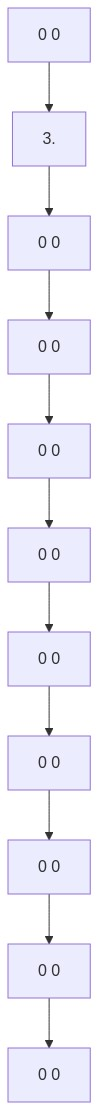

Mermaid Code:


```mermaid
graph TD;
    Node0["0 0"]
    Node1["3."]
    Node0 --> Node1
    Node2["0 0"]
    Node1 --> Node2
    Node3["0 0"]
    Node2 --> Node3
    Node4["0 0"]
    Node3 --> Node4
    Node5["0 0"]
    Node4 --> Node5
    Node6["0 0"]
    Node5 --> Node6
    Node7["0 0"]
    Node6 --> Node7
    Node8["0 0"]
    Node7 --> Node8
    Node9["0 0"]
    Node8 --> Node9
    Node10["0 0"]
    Node9 --> Node10

```


Processing sketch-data\flow-chart\flowchart (2).jpg...
Found 31 boxes.
  Box 0: 0 1
  Box 1: Leighton
  Box 2: 0 0
  Box 3: 0 0
  Box 4: 0 0
  Box 5: 4th
  Box 6: 0 0
  Box 7: 0 0
  Box 8: 0 0
  Box 9: 0 0
  Box 10: 0 0
  Box 11: 0 0
  Box 12: 0 0
  Box 13: 0 0
  Box 14: 0 0
  Box 15: 0 0


In [ ]:
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# flow-chart und state-diagram Verzeichnis
sketch_dirs = glob.glob("sketch-data/*")

num_processed = 0

for d in sketch_dirs:
    if not os.path.isdir(d): continue
    
    diagram_type = os.path.basename(d)
    print(f"\n=== Processing directory: {diagram_type} ===")
    
    images = glob.glob(os.path.join(d, "*.jpg"))
    for img_path in images:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        print(f"\nProcessing {img_path}...")
        
        # 1. Segmente
        vis_img, crops = preprocess_and_segment(img_path)
        if not crops:
            print("No boxes found.")
            continue
            
        print(f"Found {len(crops)} boxes.")
        
        # 2. HTR
        recognized_texts = []
        for i, crop in enumerate(crops):
            text = recognize_handwriting(crop)
            recognized_texts.append(text)
            print(f"  Box {i}: {text}")
            
        # 3. Mermaid Code Generierung
        mermaid_code = generate_mermaid_code(diagram_type, recognized_texts)
        
        mmd_path = os.path.join(output_dir, f"{diagram_type}_{base_name}.mmd")
        with open(mmd_path, "w") as f:
            f.write(mermaid_code)
            
        # 4. Mermaid API Rendering
        png_path = os.path.join(output_dir, f"{diagram_type}_{base_name}.png")
        if render_mermaid_to_image(mermaid_code, png_path):
            print(f"Saved generated diagram to {png_path}")
            display(IPyImage(filename=png_path))
        else:
            print(f"Failed to generate diagram image for {base_name}")
            
        print("Mermaid Code:")
        display(Markdown(f"```mermaid\n{mermaid_code}\n```"))
        
        num_processed += 1

print(f"\nProcessed {num_processed} images.")
